# Mutual Fund Analytics Capstone

## Exploratory Data Analysis (EDA)

This notebook contains the Exploratory Data Analysis (EDA) performed on the Mutual Fund Analytics dataset.

Author: Malladi Sujith Babu

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

transactions = pd.read_csv("../data/processed/clean_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [4]:
datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)

Fund Master
(40, 15)
NAV
(46000, 3)
AUM
(90, 5)
SIP
(48, 6)
Category
(144, 3)
Folios
(21, 6)
Performance
(40, 19)
Transactions
(32778, 13)
Portfolio
(322, 8)
Benchmark
(8050, 3)


# Chart 1: Daily NAV Trend Analysis (2022–2026)

This chart visualizes the daily Net Asset Value (NAV) of all mutual fund schemes from 2022 to 2026. The shaded regions indicate the 2023 bull market and the 2024 market correction.

In [5]:
import pandas as pd
import plotly.express as px

# Merge NAV with scheme names
nav_plot = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

# Convert date column
nav_plot['date'] = pd.to_datetime(nav_plot['date'])

# Filter required period
nav_plot = nav_plot[
    (nav_plot['date'] >= "2022-01-01") &
    (nav_plot['date'] <= "2026-12-31")
]

# Create interactive line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022–2026)"
)

# Highlight Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run"
)

# Highlight Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme"
)

fig.show()

In [6]:
print(aum.head())

print("\n")
print(aum.dtypes)

print("\nUnique Dates:")
print(aum["date"].unique()[:10])

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

Unique Dates:
['2022-03-31' '2022-09-30' '2023-03-31' '2023-09-30' '2024-03-31'
 '2024-09-30' '2024-12-31' '2025-03-31' '2025-12-31']


# Chart 2: AUM Growth by Fund House (2022–2025)

This chart compares the Assets Under Management (AUM) of major fund houses from 2022 to 2025. SBI Mutual Fund is highlighted to show its market leadership.

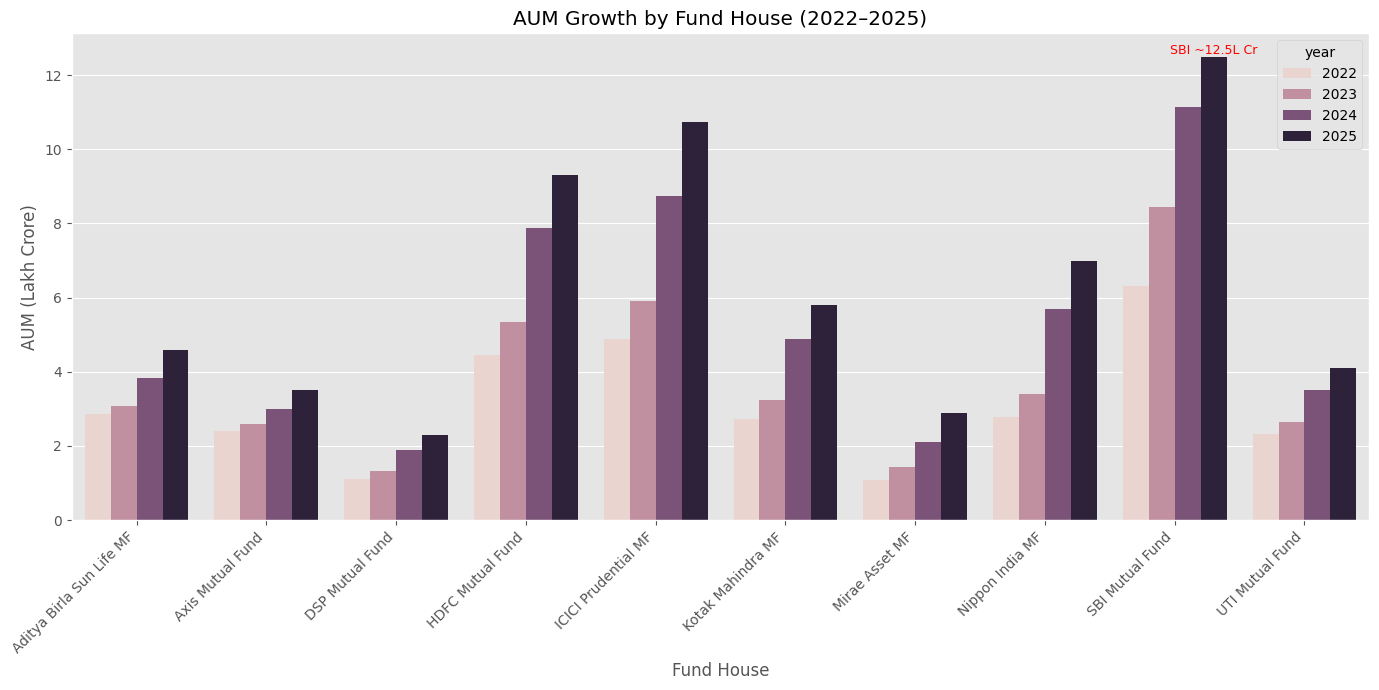

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataset
aum_plot = aum.copy()

# Convert date
aum_plot["date"] = pd.to_datetime(aum_plot["date"])

# Extract year
aum_plot["year"] = aum_plot["date"].dt.year

# Keep one record per fund per year (latest available)
aum_plot = (
    aum_plot
    .sort_values("date")
    .groupby(["fund_house", "year"])
    .last()
    .reset_index()
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_plot,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.title("AUM Growth by Fund House (2022–2025)")

# Highlight SBI
for p in ax.patches:
    if p.get_height() >= 12:
        ax.annotate(
            "SBI ~12.5L Cr",
            (p.get_x()+p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9,
            color="red"
        )

plt.tight_layout()
plt.show()

### Insight 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, reaching approximately ₹12.5 lakh crore by 2025, demonstrating its strong market leadership.

# Chart 3: Monthly SIP Inflow Trend (2022–2025)

This chart shows the monthly SIP inflows from January 2022 to December 2025. The highest SIP inflow is highlighted.

In [8]:
import pandas as pd
import plotly.express as px

# Create a copy
sip_plot = sip.copy()

# Convert month to datetime
sip_plot["month"] = pd.to_datetime(sip_plot["month"])

# Sort by month
sip_plot = sip_plot.sort_values("month")

# Create line chart
fig = px.line(
    sip_plot,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022–2025)"
)

# Find maximum SIP inflow
max_row = sip_plot.loc[sip_plot["sip_inflow_crore"].idxmax()]

# Annotate highest value
fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest: ₹{max_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)",
    height=600
)

fig.show()

### Insight 3

Monthly SIP inflows show an increasing trend over the analysis period, indicating growing investor participation. The highest SIP inflow recorded in the dataset is highlighted on the chart.

# Chart 4: Category-wise Net Inflow Heatmap

This heatmap visualizes the monthly net inflows across different mutual fund categories. Darker colors indicate higher net inflows.

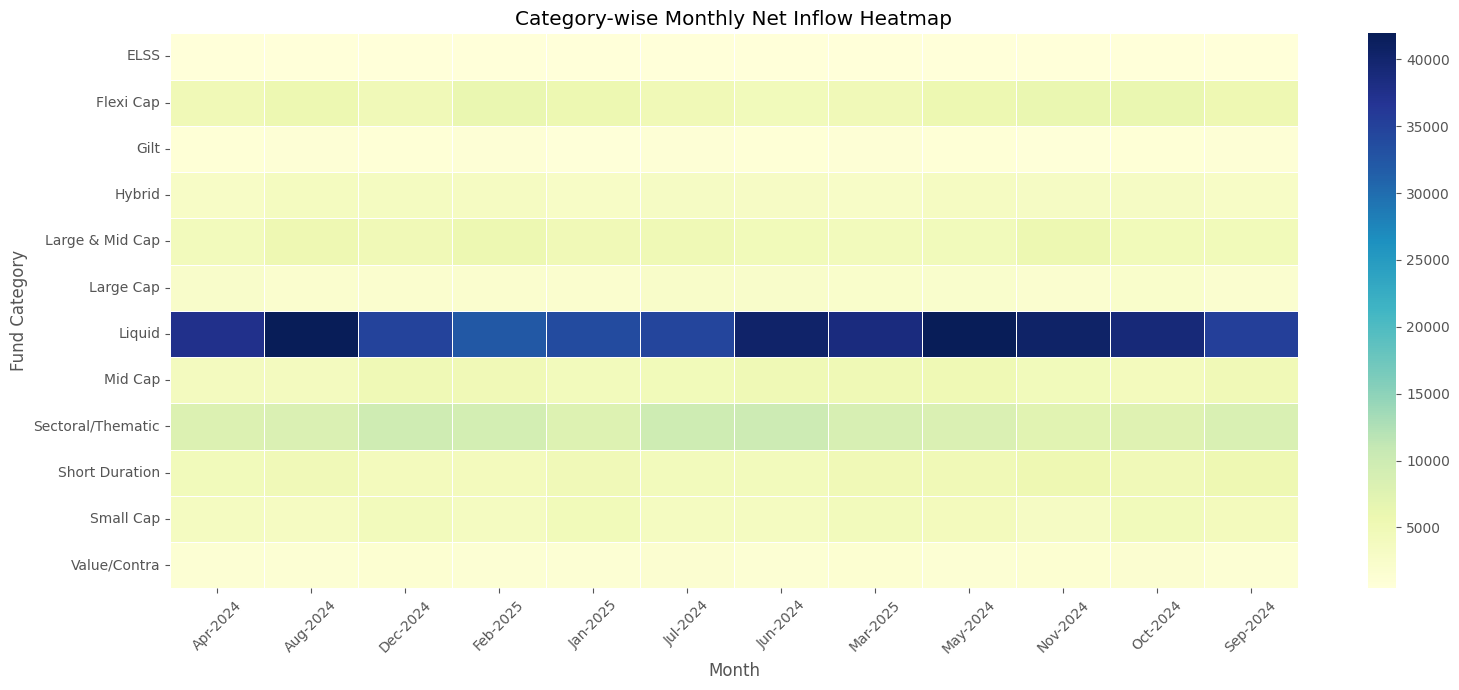

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataset
category_plot = category.copy()

# Convert month to datetime
category_plot["month"] = pd.to_datetime(category_plot["month"])

# Format month labels
category_plot["month_label"] = category_plot["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category_plot.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

# Plot heatmap
plt.figure(figsize=(16, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insight 4

Equity-oriented categories consistently recorded stronger net inflows across most months, while debt and hybrid categories exhibited greater fluctuations.

# Chart 5A: Investor Age Group Distribution

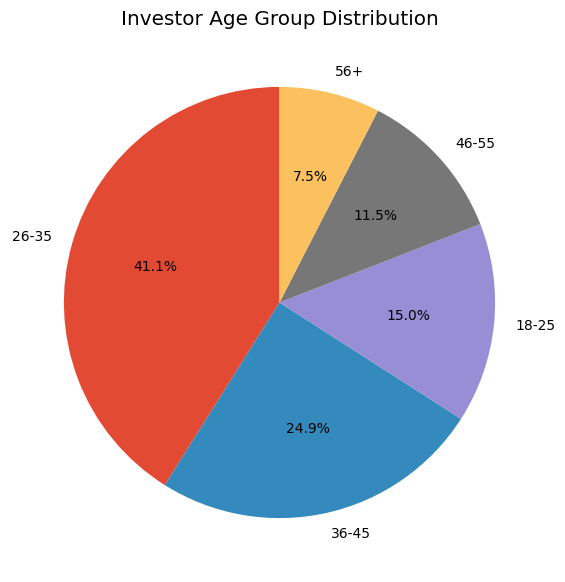

In [10]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

# Chart 5B: SIP Amount Distribution by Age Group

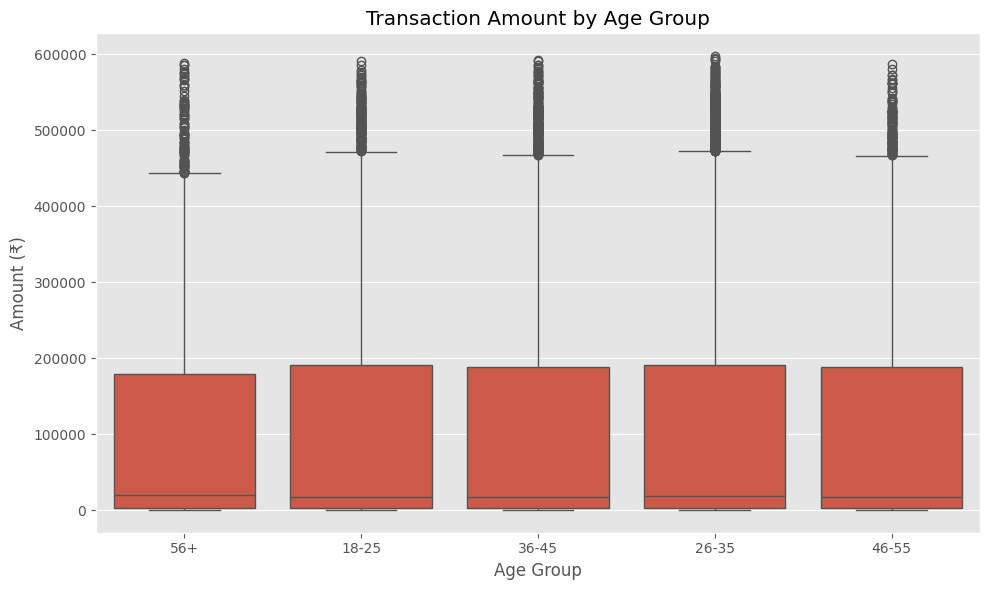

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.tight_layout()

plt.show()

# Chart 5C: Gender Distribution

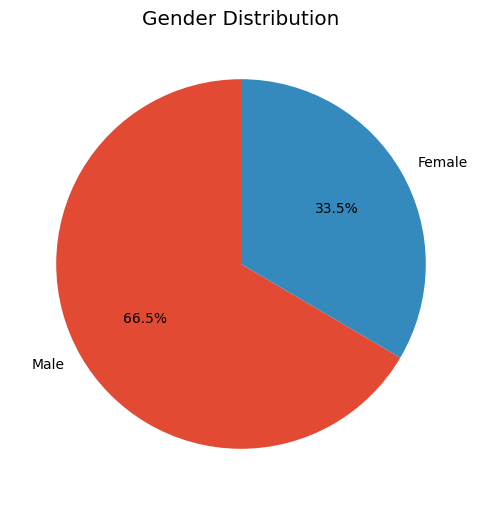

In [12]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

### Insight 5

The majority of mutual fund investors belong to the working-age population. Transaction amounts vary across age groups, and the gender distribution provides an overview of investor participation.

# Chart 6A: State-wise SIP Investment

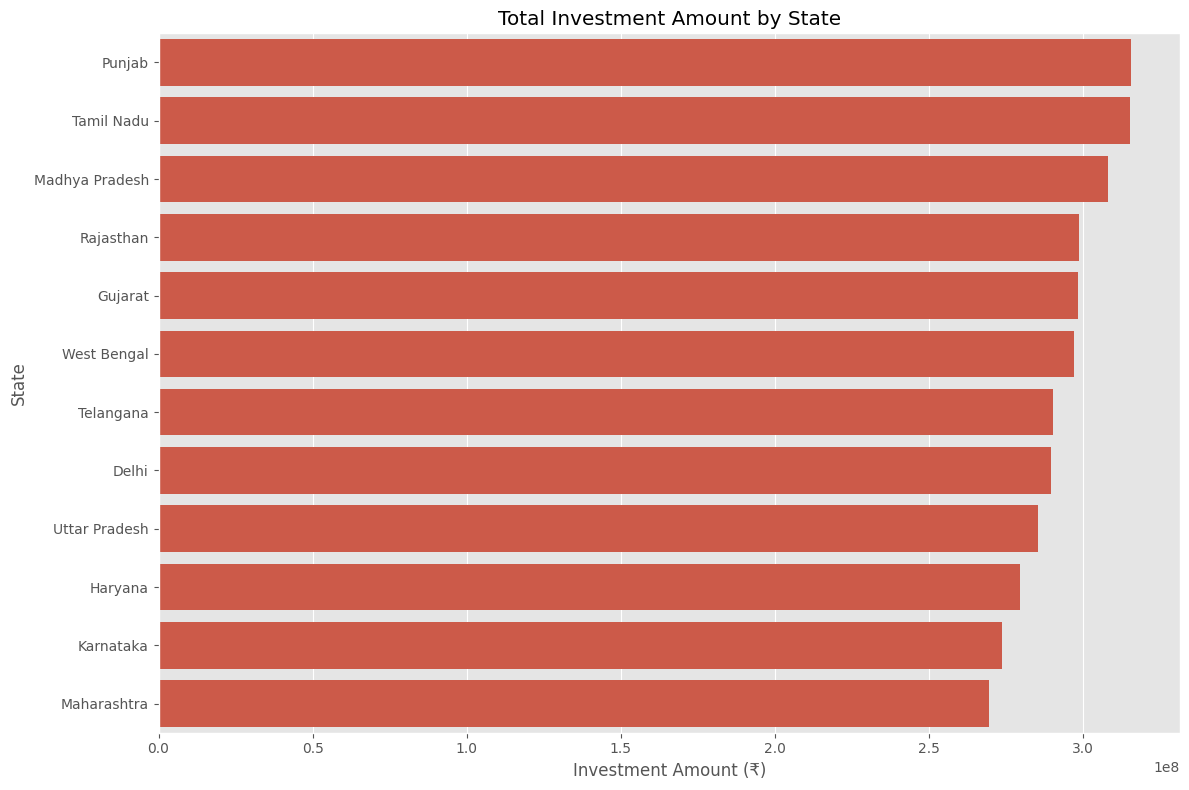

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total investment by state
state_data = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

# Chart 6B: T30 vs B30 City Tier Distribution

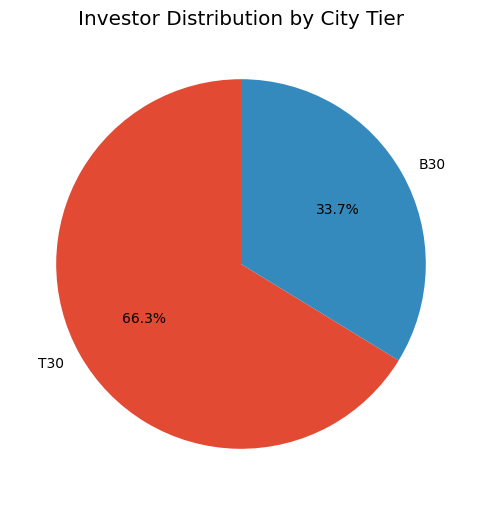

In [14]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.show()

### Insight 6

Investment activity is concentrated in a few major states. T30 cities contribute a significant share of investments, while B30 cities represent the growing potential for mutual fund penetration.

# Chart 7: Industry Folio Count Growth (2022–2025)

This chart shows the growth in mutual fund folios from 2022 to 2025 across the Indian mutual fund industry.

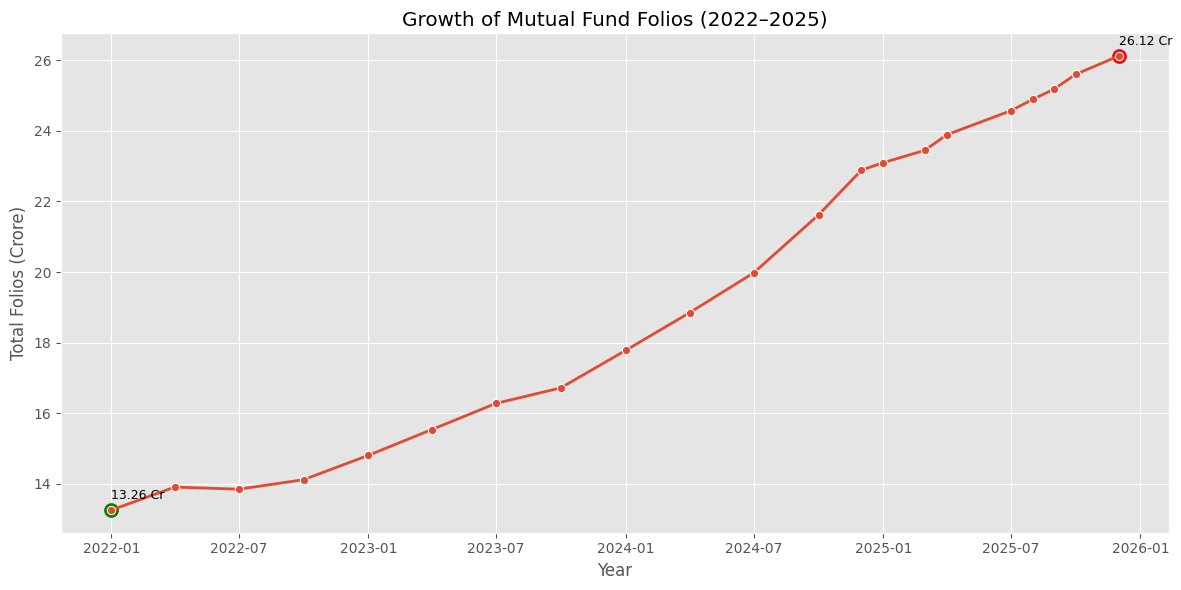

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Copy dataset
folio_plot = folios.copy()

# Convert month column
folio_plot["month"] = pd.to_datetime(folio_plot["month"])

# Sort
folio_plot = folio_plot.sort_values("month")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio_plot,
    x="month",
    y="total_folios_crore",
    marker="o",
    linewidth=2
)

# Highlight first point
plt.scatter(
    folio_plot.iloc[0]["month"],
    folio_plot.iloc[0]["total_folios_crore"],
    color="green",
    s=100
)

plt.text(
    folio_plot.iloc[0]["month"],
    folio_plot.iloc[0]["total_folios_crore"]+0.3,
    f'{folio_plot.iloc[0]["total_folios_crore"]:.2f} Cr',
    fontsize=9
)

# Highlight last point
plt.scatter(
    folio_plot.iloc[-1]["month"],
    folio_plot.iloc[-1]["total_folios_crore"],
    color="red",
    s=100
)

plt.text(
    folio_plot.iloc[-1]["month"],
    folio_plot.iloc[-1]["total_folios_crore"]+0.3,
    f'{folio_plot.iloc[-1]["total_folios_crore"]:.2f} Cr',
    fontsize=9
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

### Insight 7

The number of mutual fund folios increased consistently throughout the analysis period, indicating growing investor participation and increased awareness of mutual fund investments.

# Chart 8: NAV Return Correlation Matrix

This heatmap shows the correlation between daily NAV returns of selected mutual fund schemes.

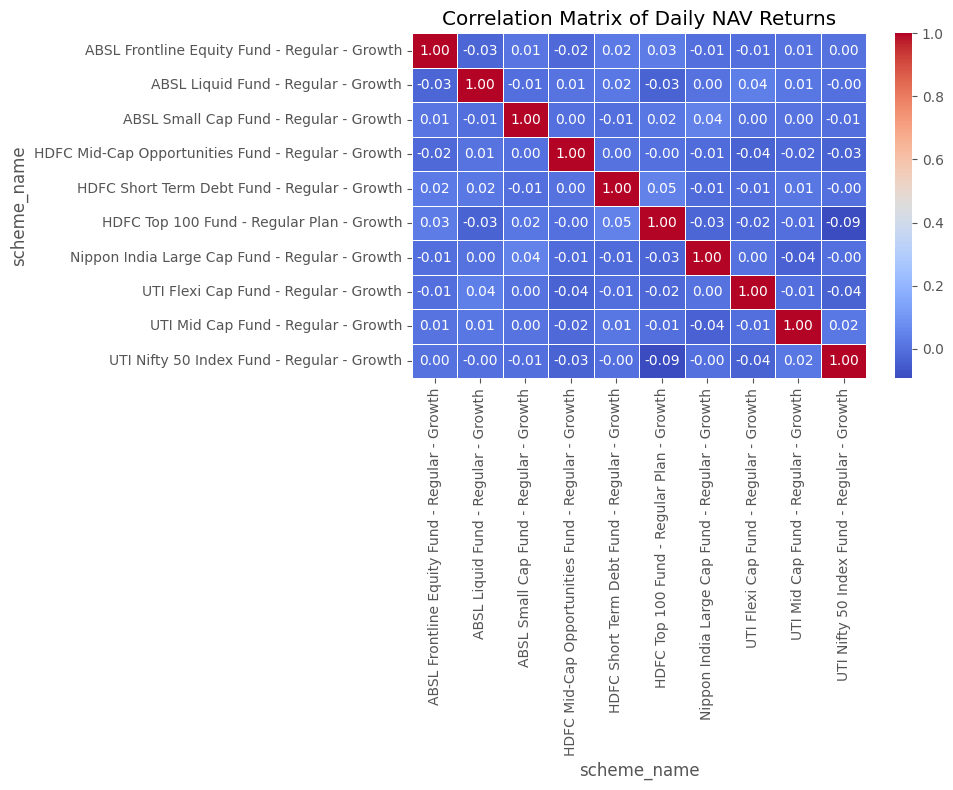

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge NAV with scheme names
corr_df = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Convert date
corr_df["date"] = pd.to_datetime(corr_df["date"])

# Select first 10 schemes
selected_schemes = corr_df["scheme_name"].unique()[:10]

corr_df = corr_df[corr_df["scheme_name"].isin(selected_schemes)]

# Pivot data
pivot_df = corr_df.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Daily returns
returns = pivot_df.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.show()

### Insight 8

Several large-cap mutual fund schemes exhibit strong positive correlations because they invest in similar market segments. Diversified categories generally show comparatively lower correlations.

# Chart 9: Sector Allocation Across Equity Mutual Funds

This donut chart represents the aggregate sector allocation across all equity mutual fund portfolios.

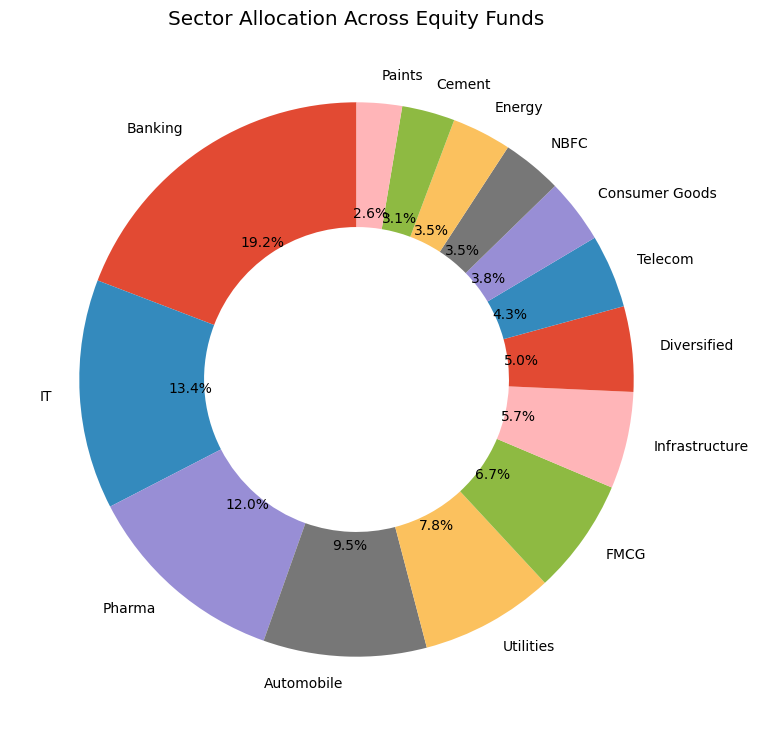

In [17]:
import matplotlib.pyplot as plt

# Aggregate sector weights
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Insight 9

Financial Services, Information Technology, Banking, and FMCG constitute the largest portfolio allocations, indicating that equity mutual funds are primarily concentrated in major market sectors.

# Chart 10: Top 10 Mutual Funds by 5-Year Return

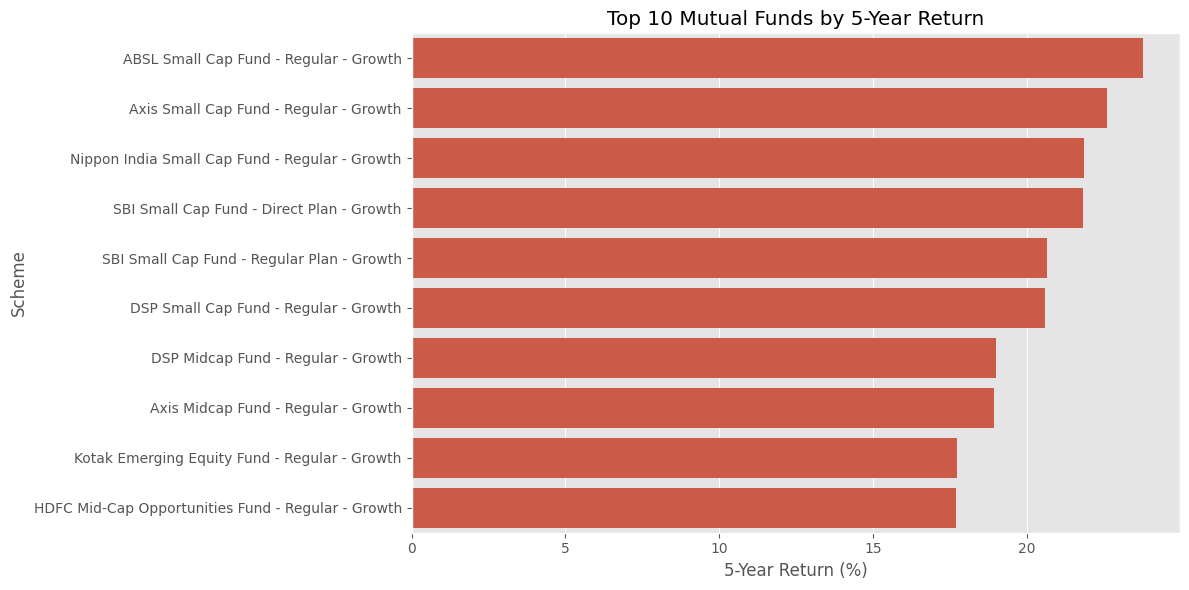

In [18]:
top10 = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by 5-Year Return")

plt.xlabel("5-Year Return (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

### Insight 10

The highest-performing schemes generated significantly better long-term returns, demonstrating the importance of selecting fundamentally strong mutual funds.

# Chart 11: Expense Ratio Distribution

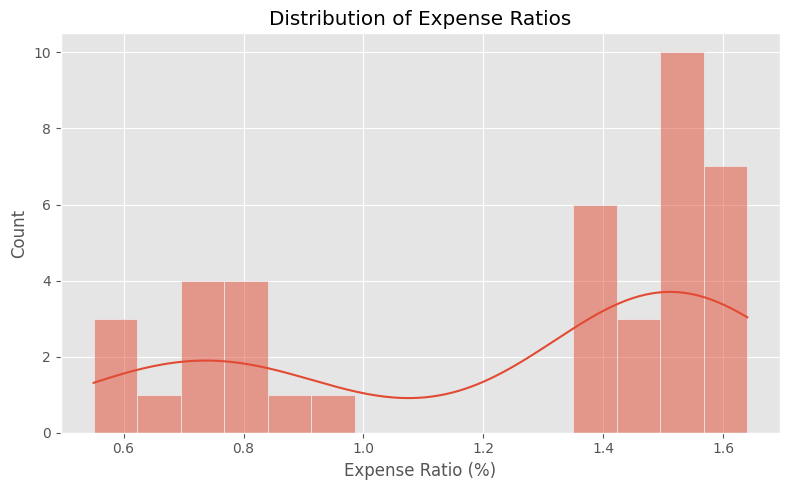

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Distribution of Expense Ratios")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.show()

# Chart 12: Risk Grade Distribution

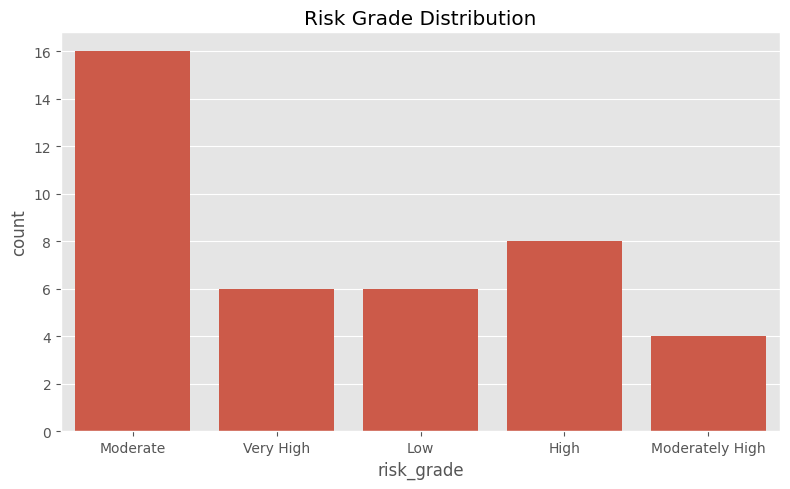

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.show()

# Chart 13: Morningstar Rating Distribution

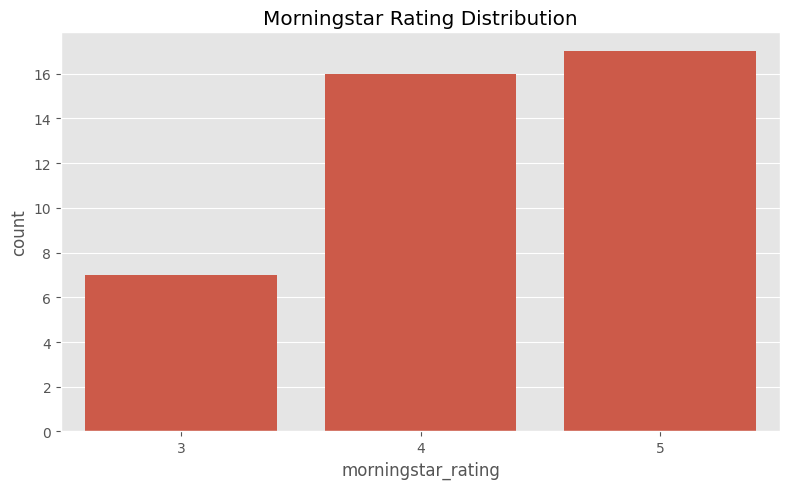

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.tight_layout()

plt.show()

# Chart 14: Average 5-Year Return by Category

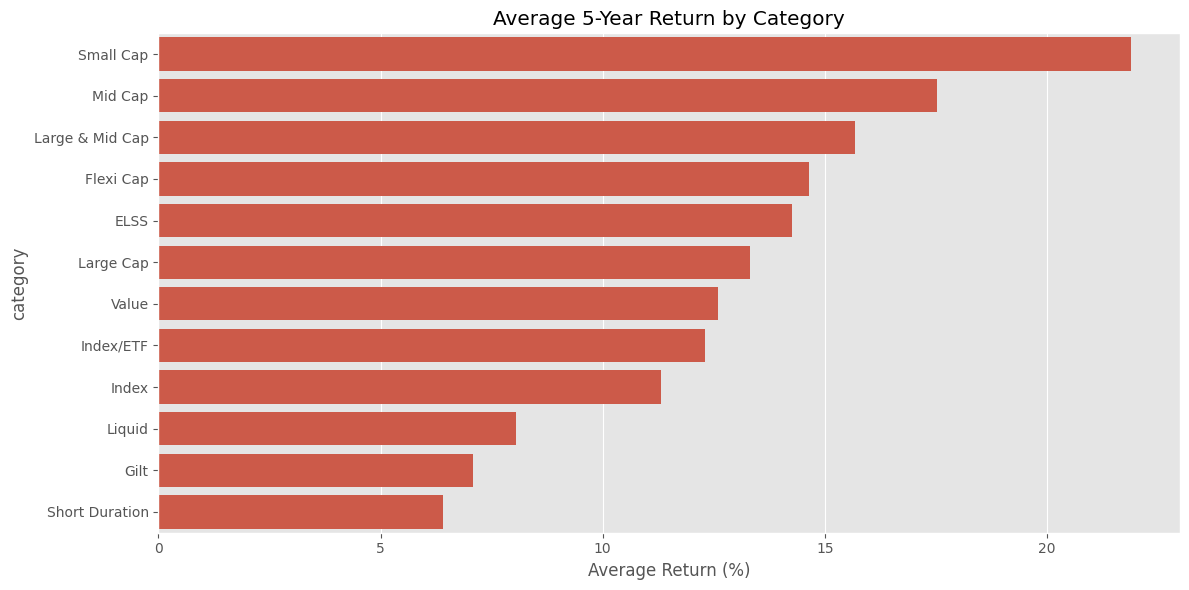

In [22]:
avg_return = (
    performance
    .groupby("category")["return_5yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_return.values,
    y=avg_return.index
)

plt.title("Average 5-Year Return by Category")

plt.xlabel("Average Return (%)")

plt.tight_layout()

plt.show()

# Chart 15: Top Fund Houses by AUM

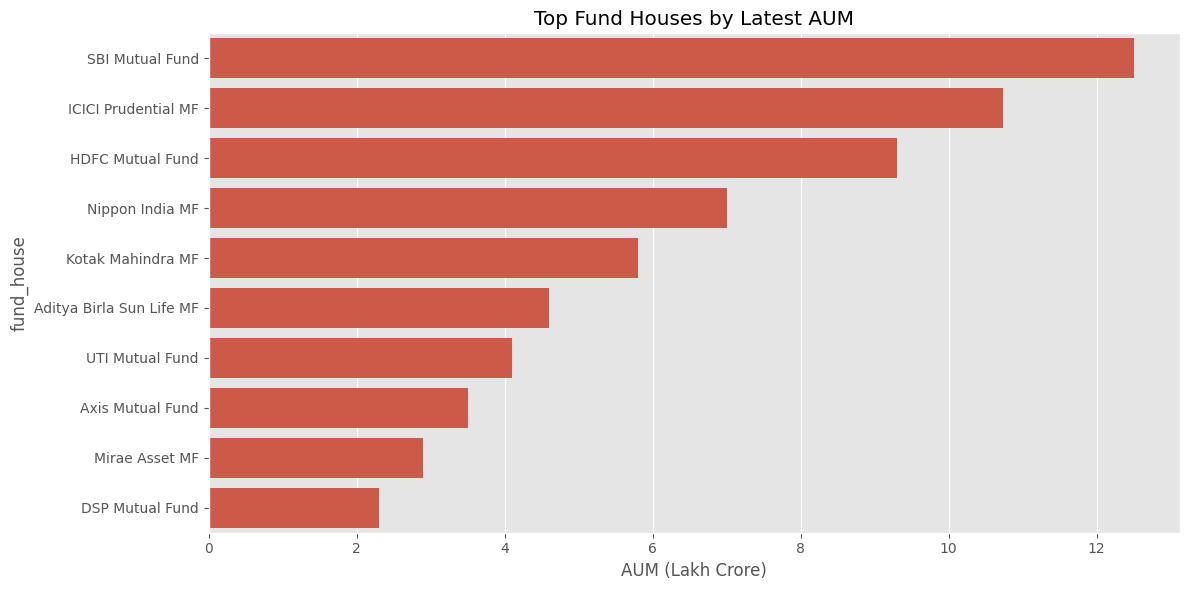

In [23]:
latest = (
    aum
    .sort_values("date")
    .groupby("fund_house")
    .last()
    .sort_values("aum_lakh_crore", ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=latest["aum_lakh_crore"],
    y=latest.index
)

plt.title("Top Fund Houses by Latest AUM")

plt.xlabel("AUM (Lakh Crore)")

plt.tight_layout()

plt.show()